<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/labexam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

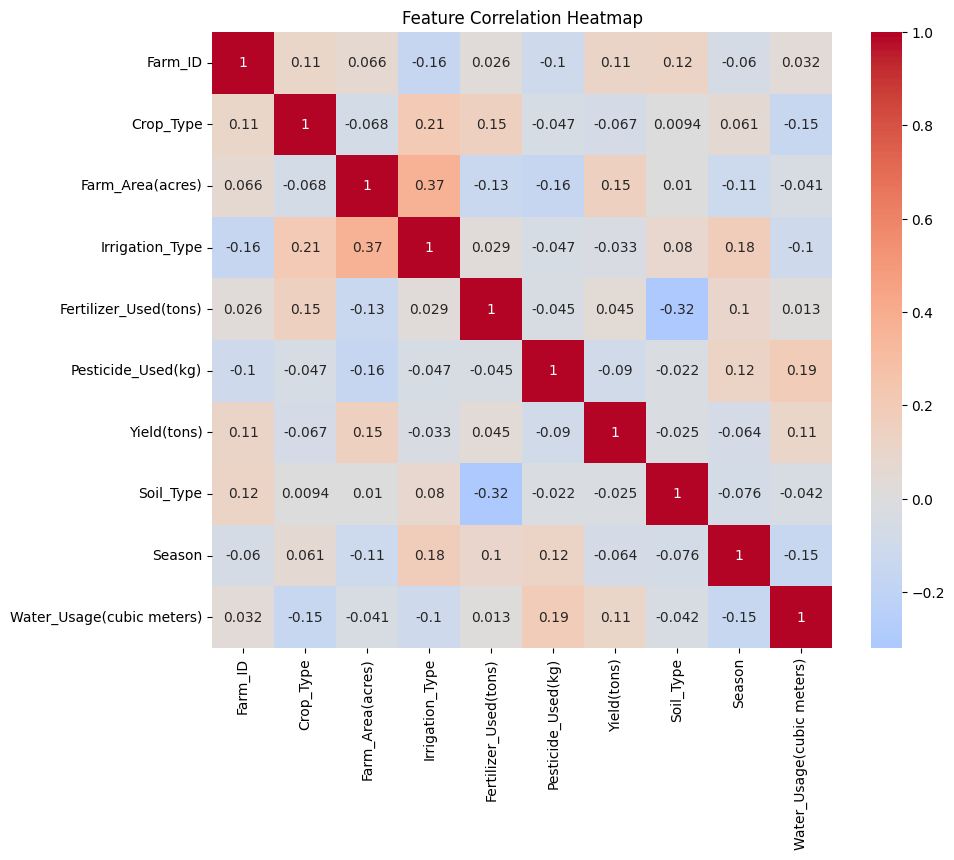

Highly correlated features to drop: []


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap

# Load dataset
df = pd.read_csv('/content/agriculture_dataset.csv')

# Step 1: Null Value Handling (Imputation)
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Impute numerical columns with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Impute categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 2: Normalization - Min-Max scaling for numerical columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Step 3: Correlation Analysis
# Encode categorical columns as integers for correlation
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

# Calculate correlation matrix
corr_matrix = df_encoded.corr()

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Step 4: Drop highly correlated features (threshold > 0.85)
high_corr_features = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            feature = corr_matrix.columns[i]
            high_corr_features.append(feature)

high_corr_features = list(set(high_corr_features))
print(f"Highly correlated features to drop: {high_corr_features}")

df_reduced = df.drop(columns=high_corr_features)



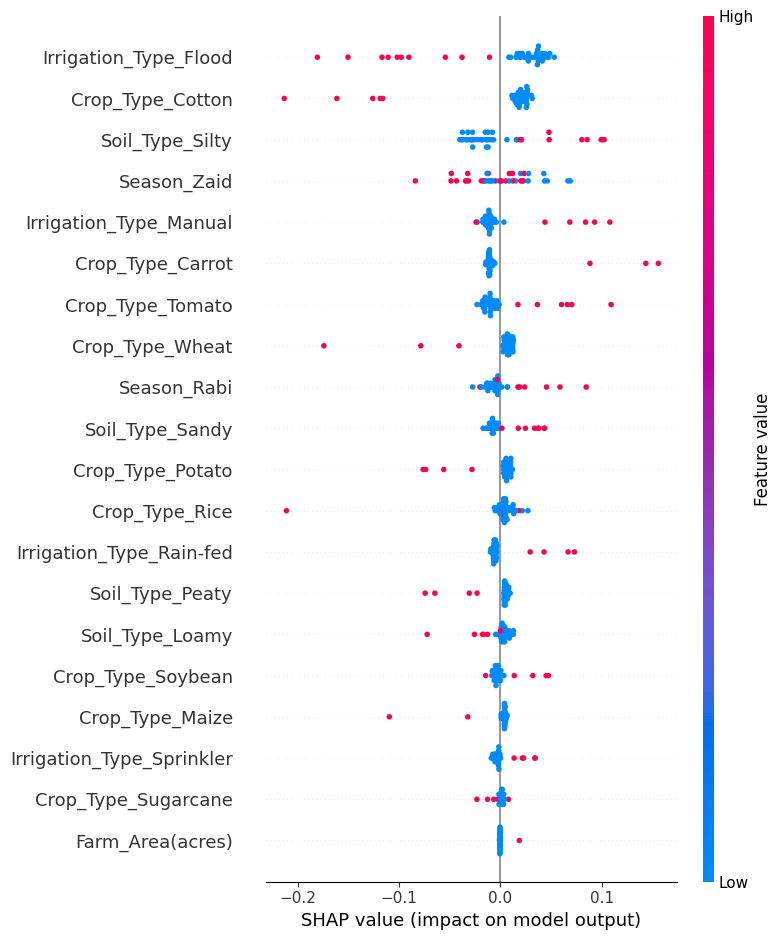

                      Feature  Mean_SHAP_Value
13      Irrigation_Type_Flood         0.047697
5            Crop_Type_Cotton         0.036857
20            Soil_Type_Silty         0.032208
22                Season_Zaid         0.024751
14     Irrigation_Type_Manual         0.020073
4            Crop_Type_Carrot         0.019423
11           Crop_Type_Tomato         0.018014
12            Crop_Type_Wheat         0.014725
21                Season_Rabi         0.013215
19            Soil_Type_Sandy         0.011974
7            Crop_Type_Potato         0.011733
8              Crop_Type_Rice         0.011728
15   Irrigation_Type_Rain-fed         0.010627
18            Soil_Type_Peaty         0.009668
17            Soil_Type_Loamy         0.007616
9           Crop_Type_Soybean         0.007175
6             Crop_Type_Maize         0.007109
16  Irrigation_Type_Sprinkler         0.006316
10        Crop_Type_Sugarcane         0.002827
0            Farm_Area(acres)         0.000933
3   Water_Usa

In [8]:
# Step 5: SHAP Analysis - Model training and explanation
# Set target variable and features
target_col = 'Yield(tons)'  # Example target for regression
X = df_reduced.drop(columns=['Farm_ID', target_col])
y = df_reduced[target_col]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Convert boolean columns to integers (0 and 1) for SHAP compatibility
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# Train Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Create SHAP explainer and get SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train)

# SHAP summary plot showing feature importance and effects
shap.summary_plot(shap_values, X_train)

# Get mean absolute SHAP values for features (global feature importance)
mean_shap_values = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_SHAP_Value': mean_shap_values
}).sort_values(by='Mean_SHAP_Value', ascending=False)

print(feature_importance)

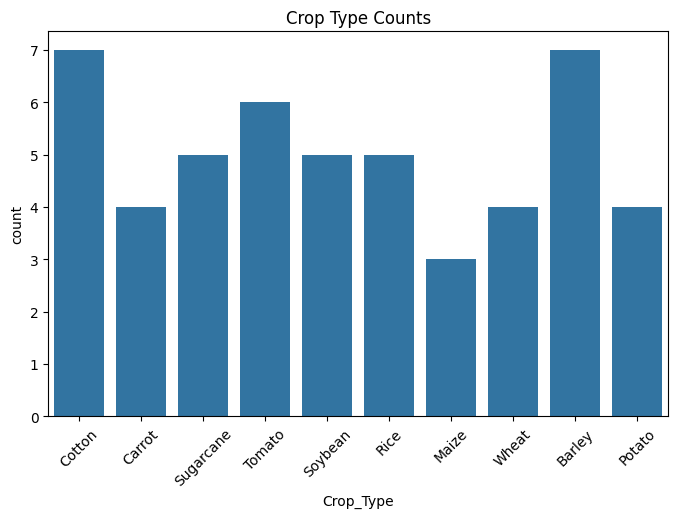

In [4]:
# 1. Bar Chart - Crop Type Counts
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Crop_Type')
plt.title('Crop Type Counts')
plt.xticks(rotation=45)
plt.show()


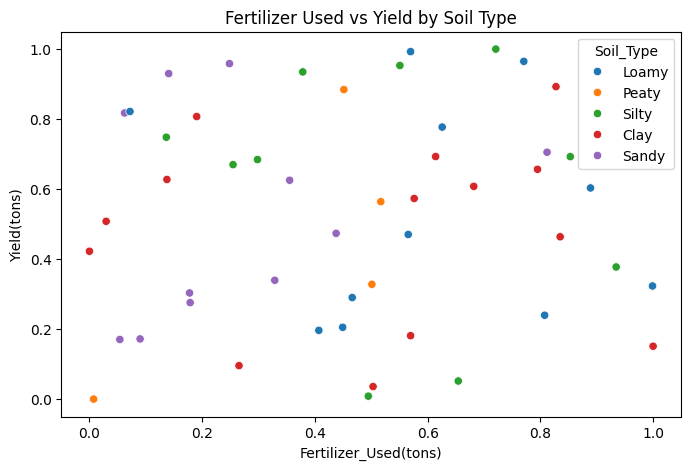

In [5]:
# 2. Scatter Plot - Fertilizer Used vs Yield by Soil Type
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Fertilizer_Used(tons)', y='Yield(tons)', hue='Soil_Type')
plt.title('Fertilizer Used vs Yield by Soil Type')
plt.show()



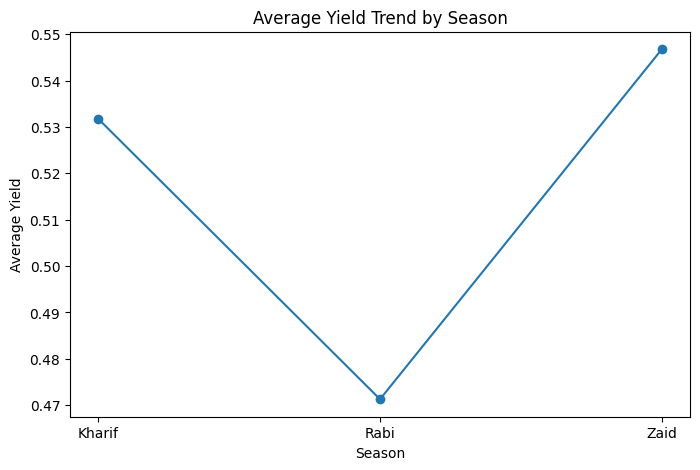

In [6]:
# 3. Line Plot - Average Yield Trend by Season
yield_season = df.groupby('Season')['Yield(tons)'].mean().reset_index()
plt.figure(figsize=(8,5))
plt.plot(yield_season['Season'], yield_season['Yield(tons)'], marker='o')
plt.title('Average Yield Trend by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield')
plt.show()

/tmp/ipython-input-252351605.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(soil_types))


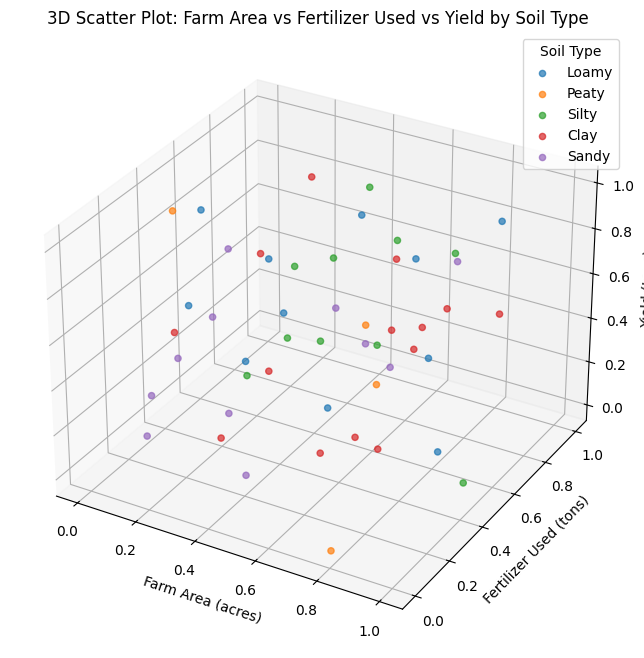

In [9]:
# Map Soil_Type to colors
soil_types = df['Soil_Type'].unique()
colors = plt.cm.get_cmap('viridis', len(soil_types))
soil_color_map = {soil: colors(i) for i, soil in enumerate(soil_types)}

# Create 3D scatter plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for soil in soil_types:
    subset = df[df['Soil_Type'] == soil]
    ax.scatter(subset['Farm_Area(acres)'], subset['Fertilizer_Used(tons)'], subset['Yield(tons)'],
               label=soil, alpha=0.7)

ax.set_xlabel('Farm Area (acres)')
ax.set_ylabel('Fertilizer Used (tons)')
ax.set_zlabel('Yield (tons)')
ax.set_title('3D Scatter Plot: Farm Area vs Fertilizer Used vs Yield by Soil Type')
ax.legend(title='Soil Type')
plt.show()

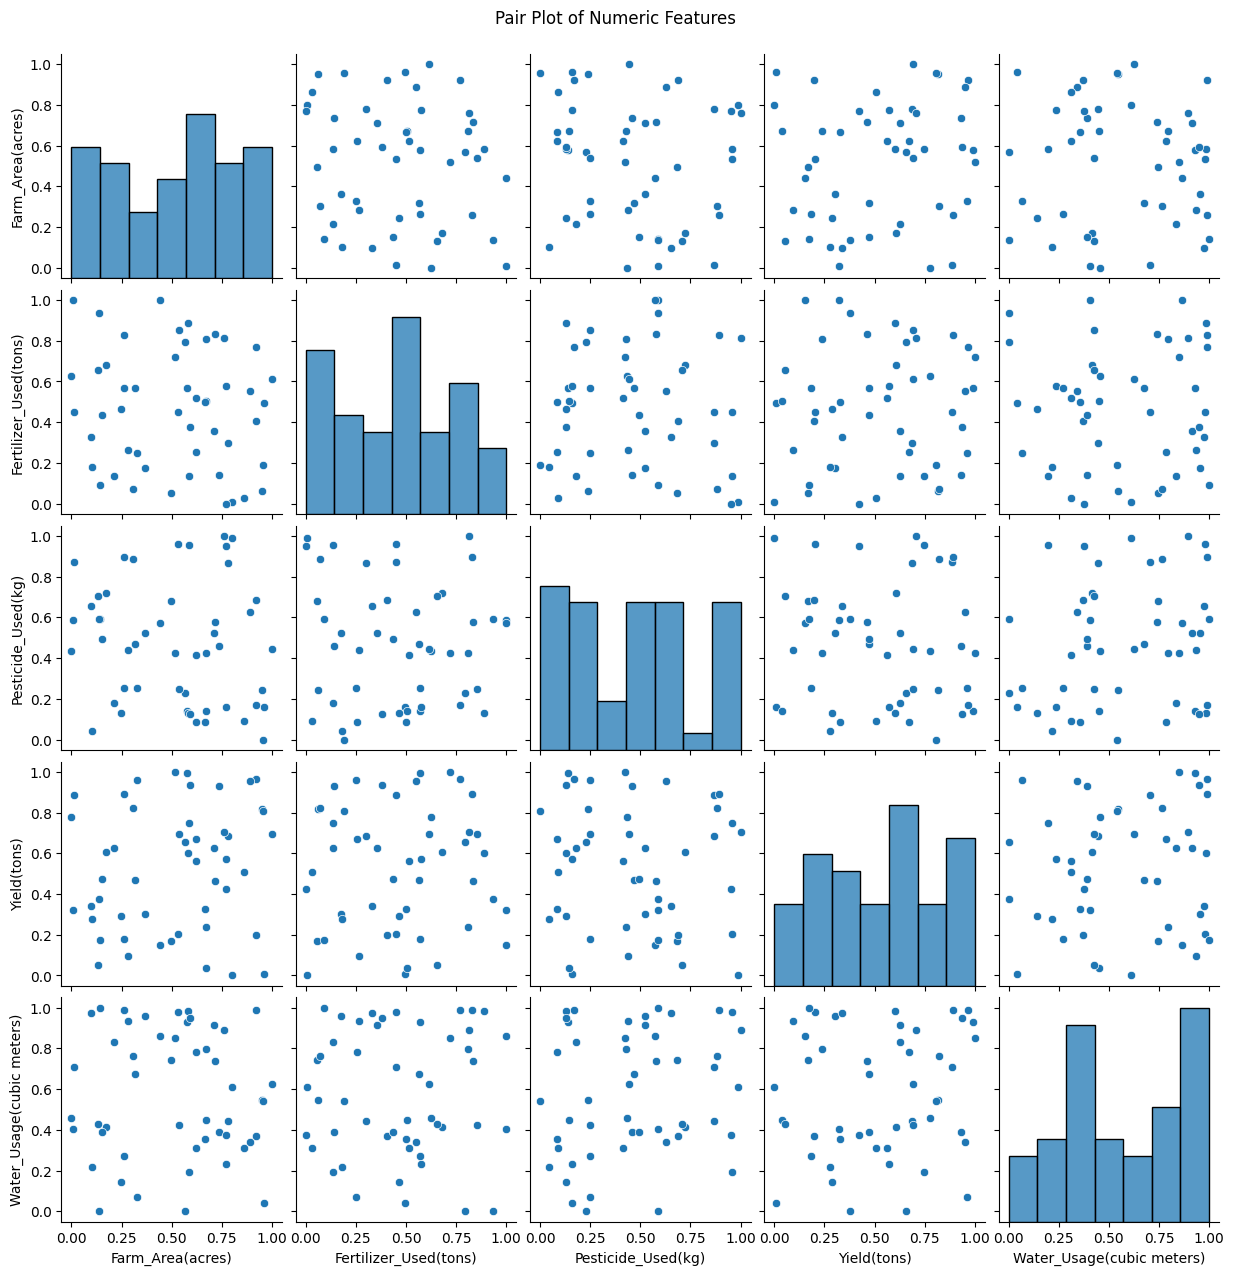

In [10]:
# 2. Pair Plot - relationships among numeric variables
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
sns.pairplot(df[num_cols])
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

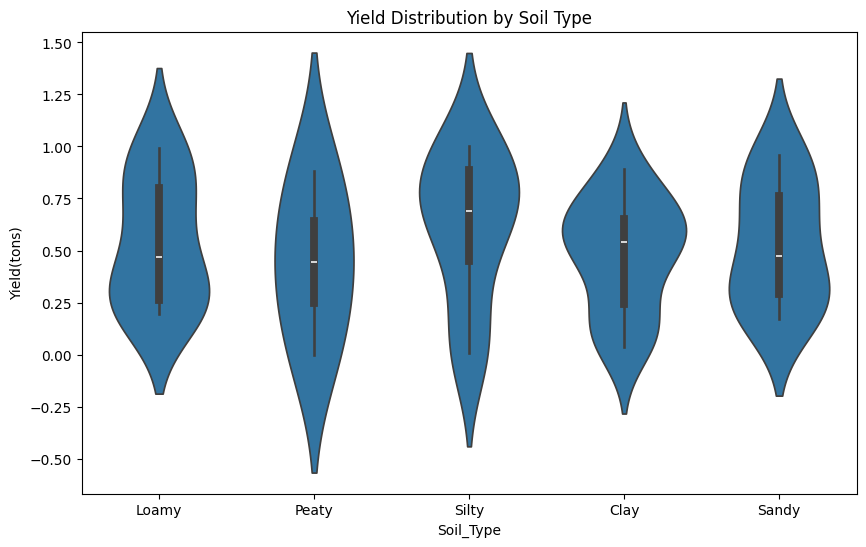

In [11]:
# 3. Violin Plot - distribution of Yield by Soil_Type
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Soil_Type', y='Yield(tons)')
plt.title('Yield Distribution by Soil Type')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, t

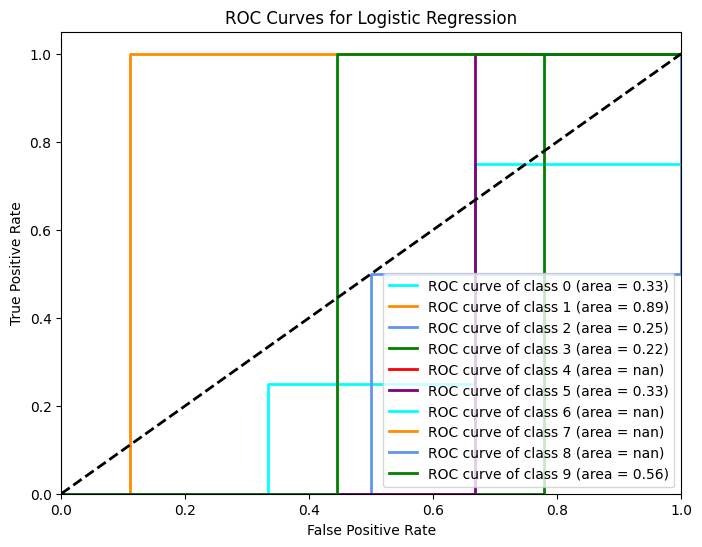

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/

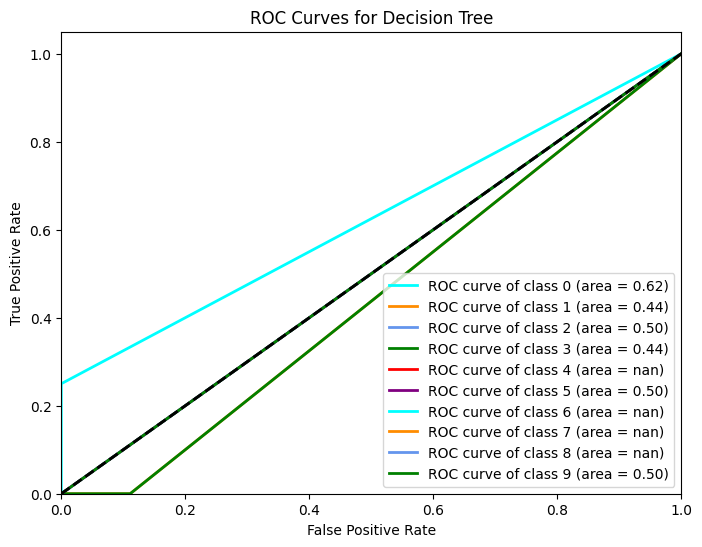

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/

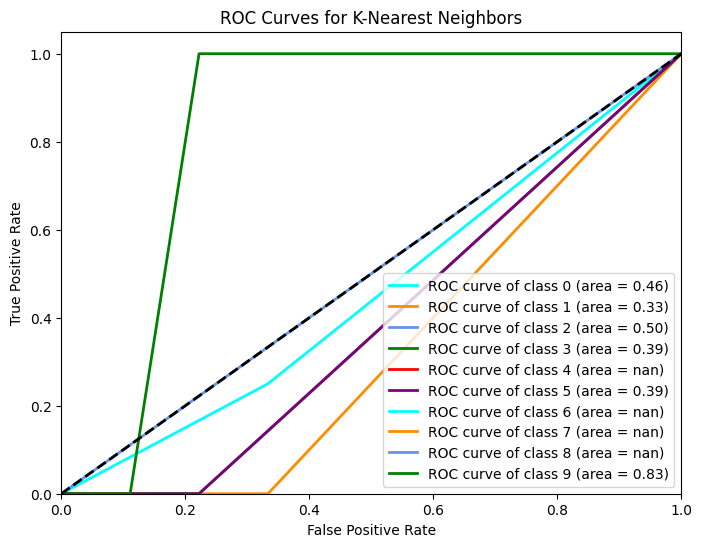

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/

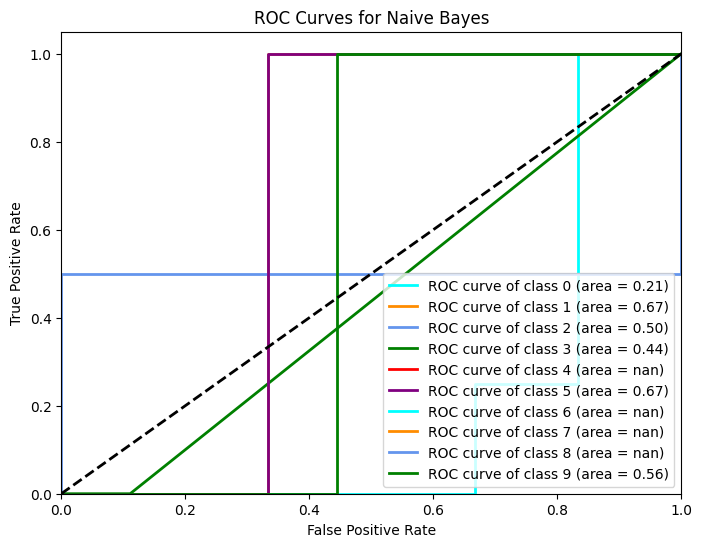

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/

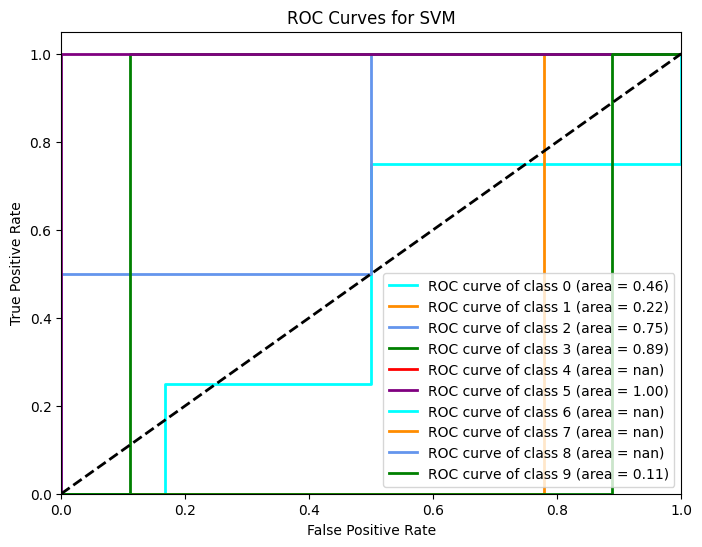


Model: Logistic Regression
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
AUC: nan
Confusion Matrix:
[[0 1 1 0 0 0 1 1 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0]]

Model: Decision Tree
Accuracy: 0.1
Precision: 0.1111111111111111
Recall: 0.027777777777777776
F1-Score: 0.044444444444444446
AUC: nan
Confusion Matrix:
[[1 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0]]

Model: K-Nearest Neighbors
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
AUC: nan
Confusion Matrix:
[[0 1 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]]

Model: Naive Bayes
Accuracy: 0.1
Precision: 0.125
Recall: 0.0625
F1-Score: 0.0833333333333333

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle

df = pd.read_csv('/content/agriculture_dataset.csv')
# Encode target and categorical features
le = LabelEncoder()
df['Crop_Type'] = le.fit_transform(df['Crop_Type'])
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(columns=['Crop_Type', 'Farm_ID'])
y = df['Crop_Type']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, multi_class='ovr'),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        model_classes = model.classes_
        test_classes = np.unique(y_test)

        if set(test_classes).issubset(set(model_classes)):
            try:
                auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', labels=model_classes)

                # ROC Curve plotting for each class
                fpr = dict()
                tpr = dict()
                roc_auc = dict()
                n_classes = len(model_classes)

                # Binarize y_test for multi-class ROC
                from sklearn.preprocessing import label_binarize
                y_test_bin = label_binarize(y_test, classes=model_classes)

                for i in range(n_classes):
                    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                    roc_auc[i] = auc(fpr[i], tpr[i])

                colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
                plt.figure(figsize=(8,6))
                for i, color in zip(range(n_classes), colors):
                    plt.plot(fpr[i], tpr[i], color=color, lw=2,
                             label=f'ROC curve of class {model_classes[i]} (area = {roc_auc[i]:0.2f})')
                plt.plot([0, 1], [0, 1], 'k--', lw=2)
                plt.xlim([0.0, 1.0])
                plt.ylim([0.0, 1.05])
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title(f'ROC Curves for {name}')
                plt.legend(loc="lower right")
                plt.show()

            except ValueError:
                auc_score = 'Error in AUC calculation'
        else:
            auc_score = 'N/A due to class mismatch'
    else:
        auc_score = 'N/A'

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'AUC': auc_score
    }

# Print results
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric, val in metrics.items():
        if metric != 'Confusion Matrix':
            print(f"{metric}: {val}")
    print(f"Confusion Matrix:\n{metrics['Confusion Matrix']}")


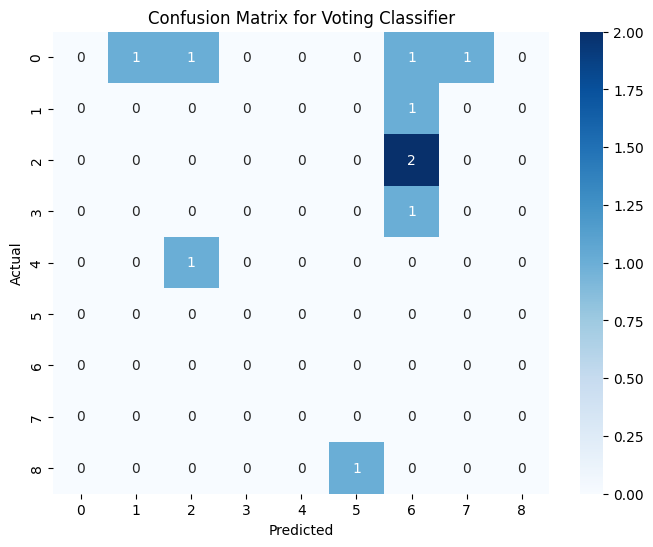

Accuracy: 0.000
Precision: 0.000
Recall: 0.000
F1-Score: 0.000


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Encode target variable
le = LabelEncoder()
df['Crop_Type'] = le.fit_transform(df['Crop_Type'])
# Encode categorical features
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(['Crop_Type', 'Farm_ID'], axis=1)
y = df['Crop_Type']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize individual classifiers
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ada = AdaBoostClassifier(n_estimators=100, random_state=42)
clf_lr = LogisticRegression(max_iter=200)

# Ensemble: Voting (hard voting)
voting_clf = VotingClassifier(estimators=[
    ('rf', clf_rf), ('ada', clf_ada), ('lr', clf_lr)
], voting='hard')

# Fit ensemble
voting_clf.fit(X_train, y_train)

# Predict
y_pred = voting_clf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Voting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print evaluation metrics
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


# Encode categorical features in X
cat_cols = df.select_dtypes(include=['object']).columns
le_features = LabelEncoder()
for col in cat_cols:
    df[col] = le_features.fit_transform(df[col])

# Prepare features and target
X = df.drop(['Crop_Type', 'Farm_ID'], axis=1)
y = df['Crop_Type']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Encode target
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)

num_classes = len(le_target.classes_) # Use the number of classes from the fitted LabelEncoder
y_train_cat = to_categorical(y_train_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

# Build MLP model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train_cat,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=2)

# Evaluate model on test set
test_loss, test_acc, test_precision, test_recall = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Predict probabilities for AUC
y_pred_prob = model.predict(X_test)

# Handle cases with only one class in y_test for AUC calculation
try:
    auc_roc = roc_auc_score(y_test_encoded, y_pred_prob, multi_class='ovr')
    print(f"Test AUC-ROC: {auc_roc:.4f}")
except ValueError as e:
    print(f"Could not calculate AUC-ROC: {e}")


# Get predicted class labels
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# Decode the labels back to original class names for the classification report
# Use inverse_transform on the unique encoded test classes to get the target names
target_names = le_target.inverse_transform(np.unique(y_test_encoded)).astype(str)

# Generate classification report with matching labels and target names
print(classification_report(y_test_encoded, y_pred_classes, labels=np.unique(y_test_encoded), target_names=target_names, zero_division=0))

# Plot training history
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 - 5s - 5s/step - accuracy: 0.0312 - loss: 2.4510 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.2044 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 2/100
1/1 - 1s - 1s/step - accuracy: 0.0938 - loss: 2.3490 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.2064 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 3/100
1/1 - 0s - 92ms/step - accuracy: 0.1562 - loss: 2.3288 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.2095 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 4/100
1/1 - 0s - 101ms/step - accuracy: 0.1875 - loss: 2.3386 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.2141 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 5/100
1/1 - 0s - 87ms/step - accuracy: 0.2500 - loss: 2.2504 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.21

TypeError: object of type 'numpy.int64' has no len()